# Data Description
[Kaggle](https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri/data)<br>
Available on [Github](https://github.com/SartajBhuvaji/Brain-Tumor-Classification-Using-Deep-Learning-Algorithms)<p>

### M1244017 高定儀 Deep Learning Final Project

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import essentails packages

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tqdm import tqdm
import os
import re
import shutil
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Flatten, Input, GlobalMaxPooling2D,GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import classification_report,confusion_matrix
import ipywidgets as widgets
import io
from PIL import Image
from IPython.display import display,clear_output
from warnings import filterwarnings

In [ ]:
!pip install mplcyberpunk
import mplcyberpunk

### Load Model

In [ ]:
model = load_model('/content/drive/MyDrive/DeepLearningProject/Final Project/efficientnetb0_brain_tumor.h5')

### Labels

In [ ]:
labels = ['glioma_tumor', 'meningioma_tumor','no_tumor', 'pituitary_tumor']
labels

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

# Data Preprocessing

## Unzip the file from google drive directly.

In [ ]:
# prompt: from google drive import zip file and unzip it

!unzip /content/drive/MyDrive/Brain Tumor Classification (MRI)_Combined.zip -d /content

## Training and Testing Data Generators
1. X_train, y_train, X_test, y_test
2. Image Resize
3. Image Regularization

In [ ]:
X_train = []
y_train = []
image_size = 224
for i in labels:
    folderPath = os.path.join('/content/drive/MyDrive/DeepLearningProject/Final Project/Brain Tumor Classification (MRI)_Combined','Train',i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size, image_size))
        X_train.append(img)
        y_train.append(i)

for i in labels:
    folderPath = os.path.join('/content/drive/MyDrive/DeepLearningProject/Final Project/Brain Tumor Classification (MRI)_Combined','Test',i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size, image_size))
        X_train.append(img)
        y_train.append(i)

X_train = np.array(X_train)
y_train = np.array(y_train)
print(y_train)

100%|██████████| 181/181 [00:01<00:00, 151.48it/s]


['glioma_tumor' 'glioma_tumor' 'glioma_tumor' ... 'pituitary_tumor'
 'pituitary_tumor' 'pituitary_tumor']


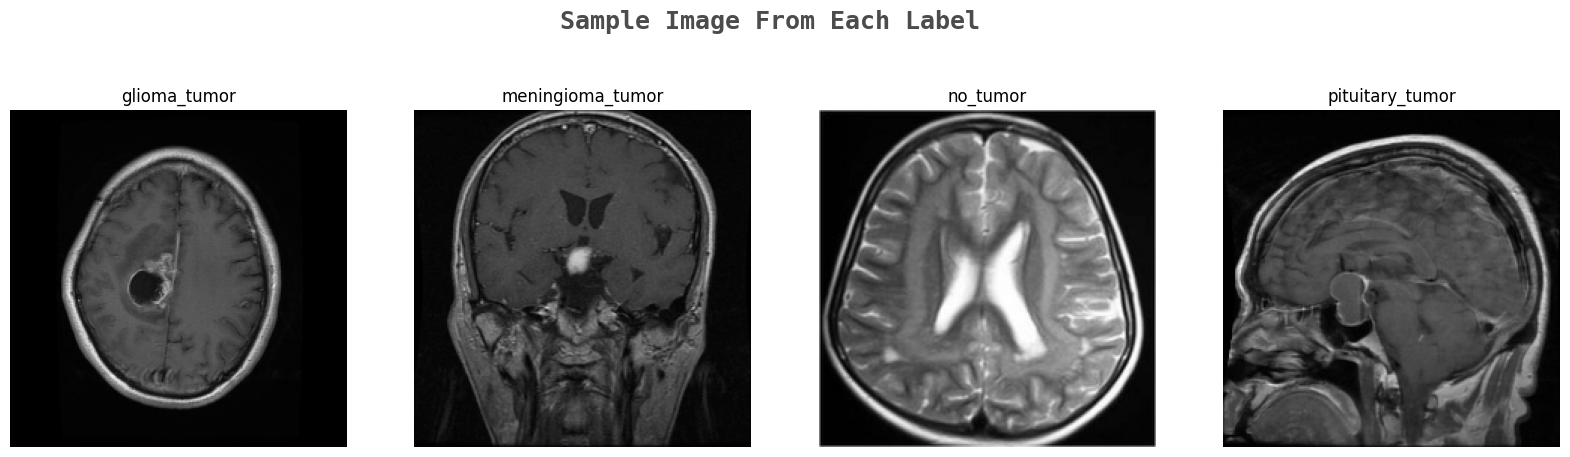

In [ ]:
k=0
fig, ax = plt.subplots(1,4,figsize=(20,20))
fig.text(s='Sample Image From Each Label',size=18,fontweight='bold',
             fontname='monospace',color="#1F1F1F",y=0.62,x=0.4,alpha=0.8)
for i in labels:
    j=0
    while True :
        if y_train[j]==i:
            ax[k].imshow(X_train[j])
            ax[k].set_title(y_train[j])
            ax[k].axis('off')
            k+=1
            break
        j+=1

In [ ]:
X_train, y_train = shuffle(X_train, y_train, random_state=111)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=111)

In [ ]:
# Assume X_train_orig and X_test_orig are the original datasets
X_train_orig = X_train.copy()
X_test_orig = X_test.copy()

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2611, 224, 224, 3)
(653, 224, 224, 3)
(2611,)
(653,)


### Image standardization

In [ ]:
print("X_train range before normalization:", X_train.min(), X_train.max())
print("X_test range before normalization:", X_test.min(), X_test.max())


# Convert the data type to float32
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

'''
# Normalize the pixel values to the range [0, 1]
X_train /= 255.0
X_test /= 255.0
'''

'''
# Calculate the mean and standard deviation of the training data
mean = np.mean(X_train, axis=(0, 1, 2), keepdims=True)
std = np.std(X_train, axis=(0, 1, 2), keepdims=True)
'''

'''
# Rescale the standardized values to the range [-1, 1]
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std
'''

'''
# Min-Max Normalization
X_train = (X_train - X_train.min()) / (X_train.max() - X_train.min())
X_test = (X_test - X_test.min()) / (X_test.max() - X_test.min())
'''

# Preprocess the images using the EfficientNetB0 preprocessing function
X_train = preprocess_input(X_train)
X_test = preprocess_input(X_test)

# Double-check ranges after normalization
print("X_train range after normalization:", X_train.min(), X_train.max())
print("X_test range after normalization:", X_test.min(), X_test.max())

X_train range before normalization: 0 255
X_test range before normalization: 0 255
X_train range after normalization: 0.0 255.0
X_test range after normalization: 0.0 255.0


### Performing **One Hot Encoding** on the labels after converting it into numerical values:

In [ ]:
y_train_new = []
for i in y_train:
    y_train_new.append(labels.index(i))
y_train = y_train_new
y_train = tf.keras.utils.to_categorical(y_train)


y_test_new = []
for i in y_test:
    y_test_new.append(labels.index(i))
y_test = y_test_new
y_test = tf.keras.utils.to_categorical(y_test)

print(y_train)
print(y_test)

[[1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 ...
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 ...
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2611, 224, 224, 3)
X_test shape: (653, 224, 224, 3)
y_train shape: (2611, 4)
y_test shape: (653, 4)


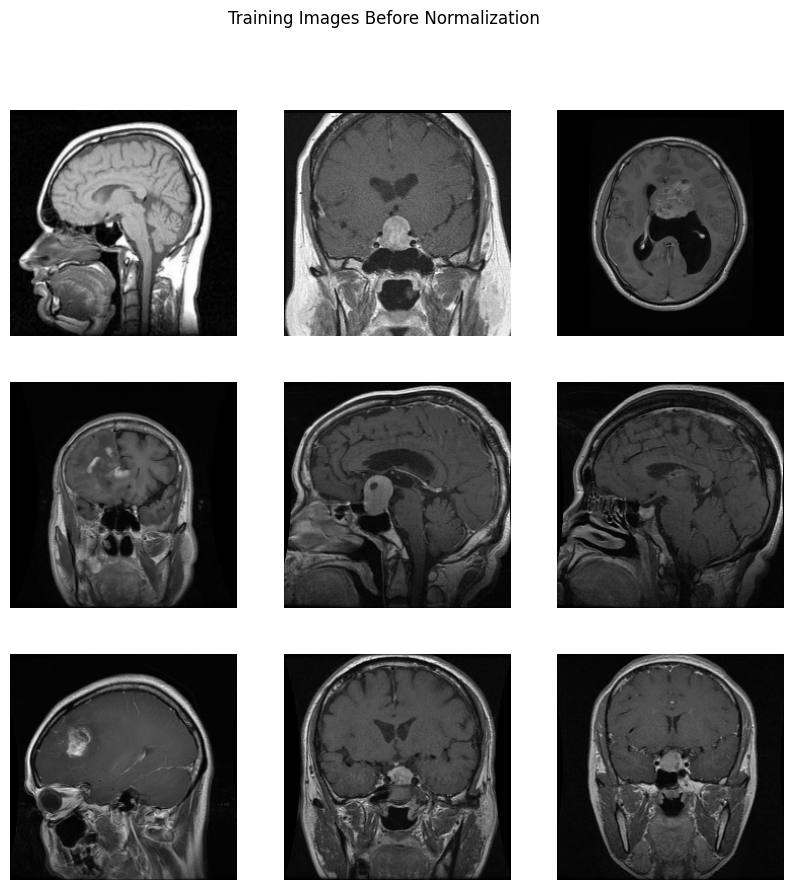

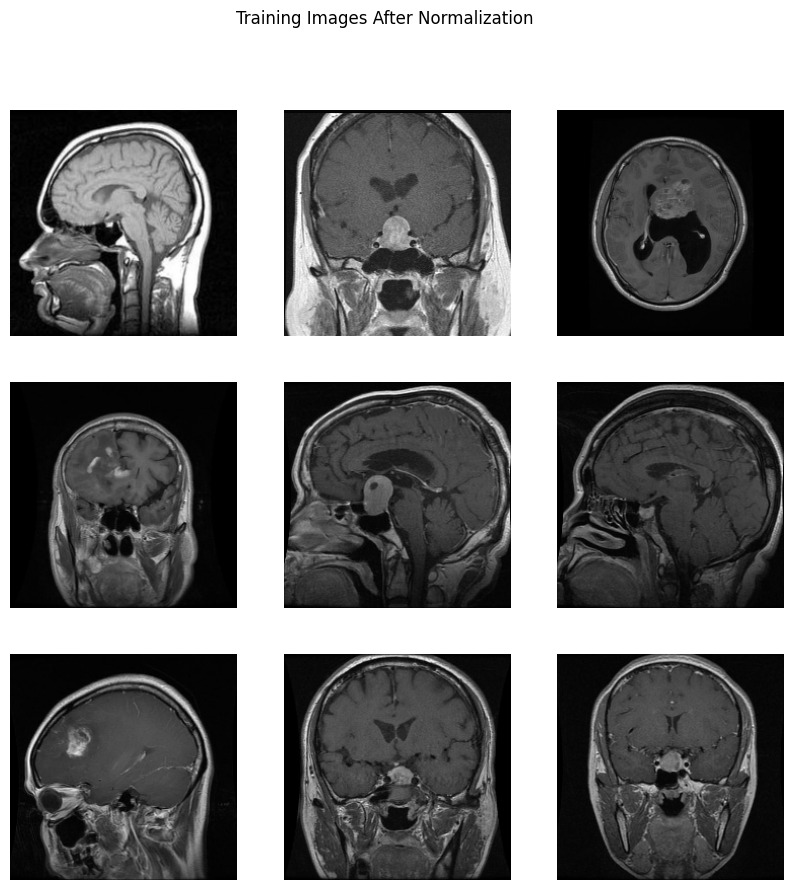

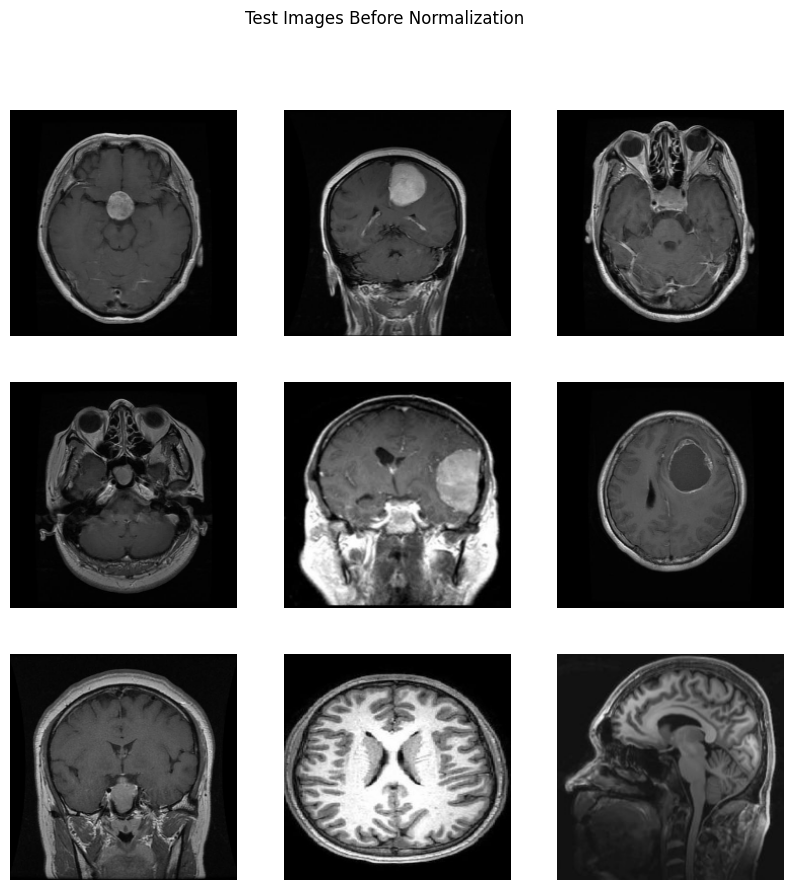

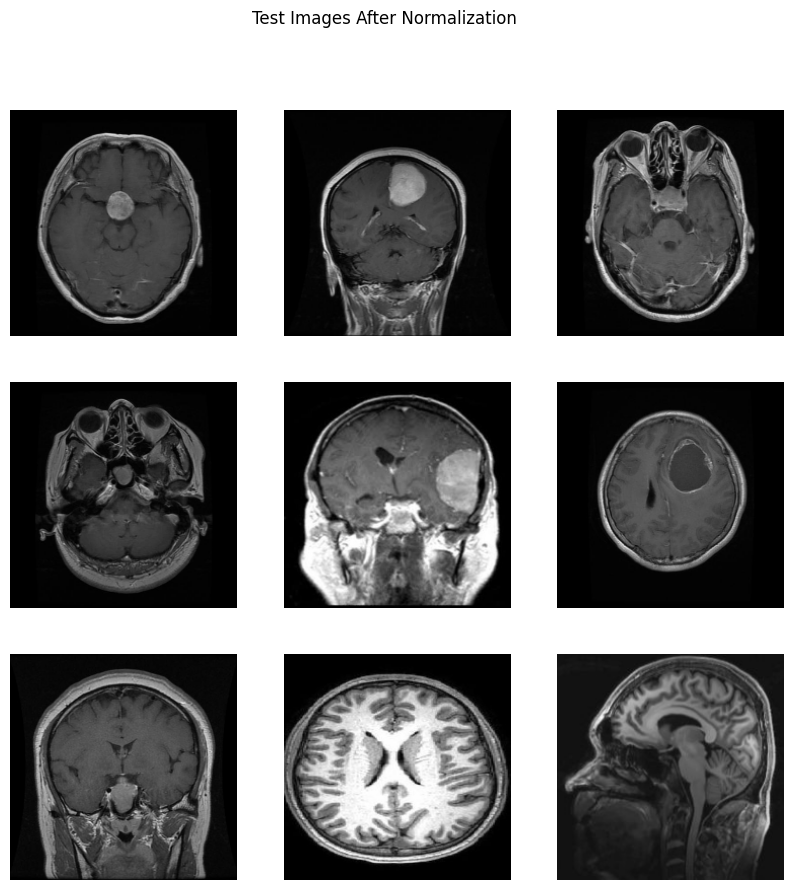

In [ ]:
# Function to display images
def show_images(images, title):
    plt.figure(figsize=(10, 10))
    for i in range(1, 10):
        plt.subplot(3, 3, i)
        plt.imshow(images[i], cmap='gray')  # or 'viridis' for color images
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Show some training images before normalization
show_images(X_train_orig, "Training Images Before Normalization")

# Show some training images after normalization
show_images(X_train, "Training Images After Normalization")

# Show some test images before normalization
show_images(X_test_orig, "Test Images Before Normalization")

# Show some test images after normalization
show_images(X_test, "Test Images After Normalization")

# Model Identification

## EfficientNetb0

In [ ]:
# Load the ResNet50 model pretrained on ImageNet without the top layers
efficientnetb0_i = tf.keras.applications.EfficientNetB0(weights='imagenet', include_top=False,
                                         input_shape=(image_size, image_size, 3))

# Build the custom model on top of the ResNet50 base
model = efficientnetb0_i.output
model = tf.keras.layers.GlobalAveragePooling2D()(model)
model = tf.keras.layers.Dropout(rate=0.5)(model)
model = tf.keras.layers.Dense(4, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(0.01))(model)
model = tf.keras.models.Model(inputs=efficientnetb0_i.input, outputs = model)

16705208/16705208 [==============================] - 0s 0us/step


### Model Compile

In [ ]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 224, 224, 3)          0         ['input_1[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, 224, 224, 3)          7         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 rescaling_1 (Rescaling)     (None, 224, 224, 3)          0         ['normalization[0][0]']   

### Data Augmentation

In [ ]:
# Define data augmentation with enhanced augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Fit the datagen on the training data
datagen.fit(X_train)

### Using tensorboard to visualize the training process

In [ ]:
# Tensorboard callback for logging training metrics
tensorboard = TensorBoard(log_dir='logs')

# Modelcheckpoint callback to save the best model
checkpoint = ModelCheckpoint("efficientnetb0.keras", monitor="val_accuracy",
                             save_best_only=True, verbose=1)

# ReduceLROnPlateau callback to reduce learning rate if validation accuracy plateaus
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=2,
                              min_delta=0.0001, verbose=1)

# Model Training

## EfficientNetb0

In [ ]:
trainefficientnetb0_history = model.fit(X_train, y_train, batch_size=128,epochs=10,validation_split=0.2,verbose=1,
                   callbacks=[tensorboard, checkpoint, reduce_lr])

Epoch 1/10
17/17 [==============================] - ETA: 0s - loss: 1.1860 - accuracy: 0.5283
Epoch 1: val_accuracy improved from -inf to 0.42830, saving model to efficientnetb0.keras
17/17 [==============================] - 124s 6s/step - loss: 1.1860 - accuracy: 0.5283 - val_loss: 1.3161 - val_accuracy: 0.4283 - lr: 1.0000e-04
Epoch 2/10
17/17 [==============================] - ETA: 0s - loss: 0.6886 - accuracy: 0.7941
Epoch 2: val_accuracy improved from 0.42830 to 0.47801, saving model to efficientnetb0.keras
17/17 [==============================] - 101s 6s/step - loss: 0.6886 - accuracy: 0.7941 - val_loss: 1.1345 - val_accuracy: 0.4780 - lr: 1.0000e-04
Epoch 3/10
17/17 [==============================] - ETA: 0s - loss: 0.4889 - accuracy: 0.8669
Epoch 3: val_accuracy improved from 0.47801 to 0.55641, saving model to efficientnetb0.keras
17/17 [==============================] - 101s 6s/step - loss: 0.4889 - accuracy: 0.8669 - val_loss: 0.9922 - val_accuracy: 0.5564 - lr: 1.0000e-04
E

# Model Evaluation

## EfficientNetb0

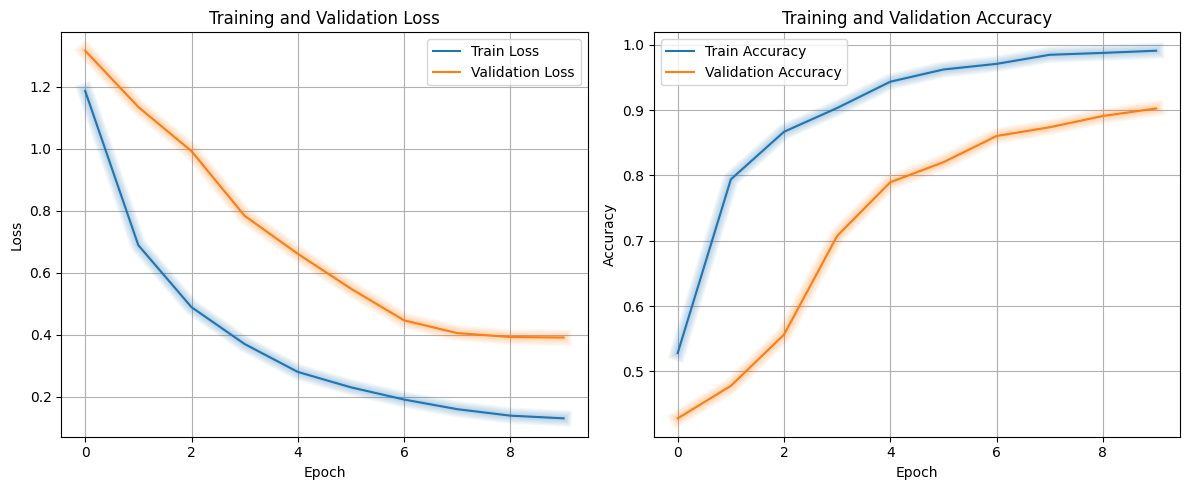

In [ ]:
# Plotting training and validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(trainefficientnetb0_history.history['loss'], label='Train Loss')
plt.plot(trainefficientnetb0_history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
mplcyberpunk.make_lines_glow()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(trainefficientnetb0_history.history['accuracy'], label='Train Accuracy')
plt.plot(trainefficientnetb0_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
mplcyberpunk.make_lines_glow()

plt.tight_layout()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(X_train, y_train)
print("訓練資料集的準確度 = %.2f" % (accuracy))

loss, accuracy = model.evaluate(X_test, y_test)
print("測試資料集的準確度 = %.2f" % (accuracy))

82/82 [==============================] - 27s 323ms/step - loss: 0.2451 - accuracy: 0.9514
訓練資料集的準確度 = 0.95
21/21 [==============================] - 7s 323ms/step - loss: 0.3236 - accuracy: 0.9096
測試資料集的準確度 = 0.91


21/21 [==============================] - 7s 289ms/step


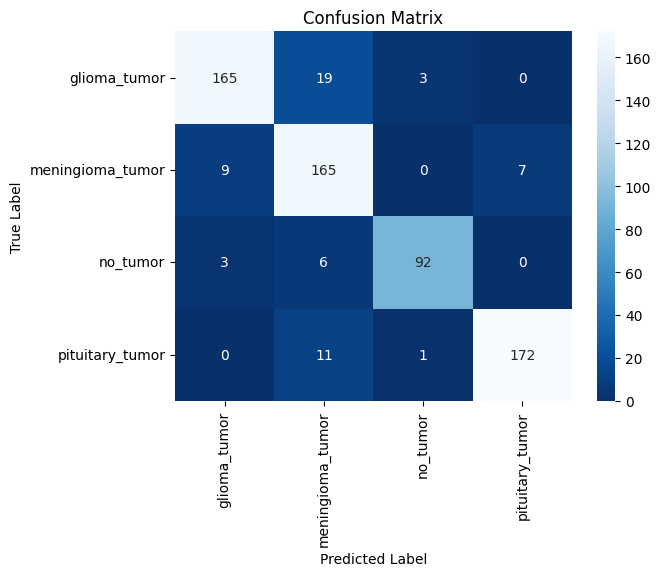

In [ ]:
y_true_test = np.argmax(y_test, axis=1)
y_pred_test = np.argmax(model.predict(X_test), axis=1)

heatmap = sns.heatmap(confusion_matrix(y_true_test,y_pred_test), annot=True, fmt='d', cmap='Blues_r',
                      xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
print(classification_report(y_true_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.93      0.88      0.91       187
           1       0.82      0.91      0.86       181
           2       0.96      0.91      0.93       101
           3       0.96      0.93      0.95       184

    accuracy                           0.91       653
   macro avg       0.92      0.91      0.91       653
weighted avg       0.91      0.91      0.91       653



### Save Model

In [ ]:
print("Saving Model: efficientnetb0_brain_tumor_revised.h5 ...")
model.save("efficientnetb0_brain_tumor_revised.h5")

Saving Model: efficientnetb0_brain_tumor_revised.h5 ...


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


# Inference (Prediction)

## EfficientNetb0

1/1 [==============================] - 0s 60ms/step
Predicted label: glioma_tumor 
Actual label: glioma_tumor 
Confidence: 99.03%



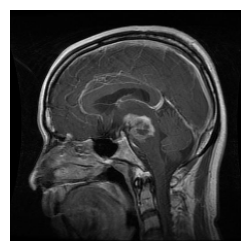

In [ ]:
random_index = np.random.randint(0, len(X_test))
random_img = X_test[random_index]
predictions = model.predict(random_img.reshape(1, 224, 224, 3))  # Reshape and preprocess the image

# Interpret the model's predictions
predicted_class = np.argmax(predictions)  # Get the index of the class with the highest probability
predicted_label = labels[predicted_class]  # Convert class to label
confidence = predictions[0][predicted_class]

actual_index = y_test[random_index]  # Get the one-hot encoded actual class
actual_class = np.argmax(actual_index)
actual_label = labels[actual_class]

# Display the image and prediction information
print(f"\033[94mPredicted label: {predicted_label}\033[0m \n\033[92mActual label: {actual_label}\033[0m \n\033[93mConfidence: {confidence*100:.2f}%\033[0m\n")
plt.figure(figsize = (3,3))
plt.imshow(random_img)
plt.axis('off')
plt.show()